In [42]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import ks_2samp, wasserstein_distance

In [58]:
# =========================================================
# 0. 설정
# =========================================================
path_2017 = r"D:\dataset\2017.csv"
path_2018 = r"D:\dataset\2018.csv"

save_dir = r"D:\dataset\label_pair_compare_top20_no_dstport"
os.makedirs(save_dir, exist_ok=True)

# 비교할 라벨 쌍
compare_pairs = [
    ("BENIGN", "BENIGN"),

    ("DDoS", "DDOS attack-HOIC"),

    ("FTP-Patator", "FTP-BruteForce"),
    ("SSH-Patator", "SSH-Bruteforce"),

    ("DoS GoldenEye", "DoS attacks-GoldenEye"),
    ("DoS Hulk", "DoS attacks-Hulk"),
    ("DoS slowloris", "DoS attacks-Slowloris"),
    ("DoS Slowhttptest", "DoS attacks-SlowHTTPTest"),

    ("Bot", "Bot")
]

# 제거할 feature
drop_feature = "Destination Port"

In [60]:
# =========================================================
# 1. 비교할 라벨 쌍 정의
# =========================================================
compare_pairs = [
    ("BENIGN", "BENIGN"),

    ("DDoS", "DDOS attack-HOIC"),

    ("FTP-Patator", "FTP-BruteForce"),
    ("SSH-Patator", "SSH-Bruteforce"),

    ("DoS GoldenEye", "DoS attacks-GoldenEye"),
    ("DoS Hulk", "DoS attacks-Hulk"),
    ("DoS slowloris", "DoS attacks-Slowloris"),
    ("DoS Slowhttptest", "DoS attacks-SlowHTTPTest"),

    ("Bot", "Bot")
]

# 제거할 feature
drop_feature = "Destination Port"


In [62]:
# =========================================================
# 2. 컬럼명 통일
# =========================================================
rename_2018_to_2017 = {
    "Dst Port": "Destination Port",
    "Tot Fwd Pkts": "Total Fwd Packets",
    "Tot Bwd Pkts": "Total Backward Packets",
    "TotLen Fwd Pkts": "Total Length of Fwd Packets",
    "TotLen Bwd Pkts": "Total Length of Bwd Packets",
    "Fwd Pkt Len Max": "Fwd Packet Length Max",
    "Fwd Pkt Len Min": "Fwd Packet Length Min",
    "Fwd Pkt Len Mean": "Fwd Packet Length Mean",
    "Fwd Pkt Len Std": "Fwd Packet Length Std",
    "Bwd Pkt Len Max": "Bwd Packet Length Max",
    "Bwd Pkt Len Min": "Bwd Packet Length Min",
    "Bwd Pkt Len Mean": "Bwd Packet Length Mean",
    "Bwd Pkt Len Std": "Bwd Packet Length Std",
    "Flow Byts/s": "Flow Bytes/s",
    "Flow Pkts/s": "Flow Packets/s",
    "Fwd IAT Tot": "Fwd IAT Total",
    "Bwd IAT Tot": "Bwd IAT Total",
    "Fwd Header Len": "Fwd Header Length",
    "Bwd Header Len": "Bwd Header Length",
    "Fwd Pkts/s": "Fwd Packets/s",
    "Bwd Pkts/s": "Bwd Packets/s",
    "Pkt Len Min": "Min Packet Length",
    "Pkt Len Max": "Max Packet Length",
    "Pkt Len Mean": "Packet Length Mean",
    "Pkt Len Std": "Packet Length Std",
    "Pkt Len Var": "Packet Length Variance",
    "FIN Flag Cnt": "FIN Flag Count",
    "SYN Flag Cnt": "SYN Flag Count",
    "RST Flag Cnt": "RST Flag Count",
    "PSH Flag Cnt": "PSH Flag Count",
    "ACK Flag Cnt": "ACK Flag Count",
    "URG Flag Cnt": "URG Flag Count",
    "ECE Flag Cnt": "ECE Flag Count",
    "Pkt Size Avg": "Average Packet Size",
    "Fwd Seg Size Avg": "Avg Fwd Segment Size",
    "Bwd Seg Size Avg": "Avg Bwd Segment Size",
    "Subflow Fwd Pkts": "Subflow Fwd Packets",
    "Subflow Fwd Byts": "Subflow Fwd Bytes",
    "Subflow Bwd Pkts": "Subflow Bwd Packets",
    "Subflow Bwd Byts": "Subflow Bwd Bytes",
    "Init Fwd Win Byts": "Init_Win_bytes_forward",
    "Init Bwd Win Byts": "Init_Win_bytes_backward",
}

drop_cols = ["Protocol", "Timestamp", "Fwd Header Length.1"]

In [64]:
# =========================================================
# 3. 라벨 정리
# =========================================================
def clean_label(x):
    x = str(x).strip()

    # 깨진 문자 처리
    x = x.replace("�", "-")
    x = x.replace("–", "-")

    # Web Attack 깨짐 처리
    x = x.replace("Web Attack � Brute Force", "Web Attack - Brute Force")
    x = x.replace("Web Attack � XSS", "Web Attack - XSS")
    x = x.replace("Web Attack � Sql Injection", "Web Attack - Sql Injection")

    # 공백 정리
    x = " ".join(x.split())

    # benign 통일
    if x.lower() == "benign":
        return "BENIGN"

    return x


In [66]:
# =========================================================
# 3. 데이터 로드
# =========================================================
print("2017 읽는 중...")
df_2017 = pd.read_csv(path_2017, low_memory=True)

print("2018 읽는 중...")
df_2018 = pd.read_csv(path_2018, low_memory=True)

# 컬럼 공백 제거
df_2017.columns = df_2017.columns.str.strip()
df_2018.columns = df_2018.columns.str.strip()

# 2018 컬럼명 통일
df_2018.rename(columns=rename_2018_to_2017, inplace=True)

# 불필요 컬럼 제거
df_2017.drop(columns=[c for c in drop_cols if c in df_2017.columns], inplace=True)
df_2018.drop(columns=[c for c in drop_cols if c in df_2018.columns], inplace=True)

# 라벨 정리
df_2017["Label"] = df_2017["Label"].apply(clean_label)
df_2018["Label"] = df_2018["Label"].apply(clean_label)

# 공통 컬럼만 사용
common_cols = list(set(df_2017.columns).intersection(set(df_2018.columns)))
common_cols = [c for c in common_cols if c != "Label"] + ["Label"]

df_2017 = df_2017[common_cols].copy()
df_2018 = df_2018[common_cols].copy()

# =========================================================
# 4. 숫자형 변환 / 기본 정리
# =========================================================
feature_cols = [c for c in common_cols if c != "Label"]

for col in feature_cols:
    df_2017[col] = pd.to_numeric(df_2017[col], errors="coerce")
    df_2018[col] = pd.to_numeric(df_2018[col], errors="coerce")

for df in [df_2017, df_2018]:
    df.replace([np.inf, -np.inf], np.nan, inplace=True)

    if "Flow Duration" in df.columns:
        df.drop(df[df["Flow Duration"] < 0].index, inplace=True)

# 실제 라벨 확인
print("\n2017 labels:")
print(sorted(df_2017["Label"].dropna().unique().tolist()))

print("\n2018 labels:")
print(sorted(df_2018["Label"].dropna().unique().tolist()))

2017 읽는 중...
2018 읽는 중...

2017 labels:
['BENIGN', 'Bot', 'DDoS', 'DoS GoldenEye', 'DoS Hulk', 'DoS Slowhttptest', 'DoS slowloris', 'FTP-Patator', 'PortScan', 'SSH-Patator', 'Web Attack - Brute Force', 'Web Attack - Sql Injection', 'Web Attack - XSS']

2018 labels:
['BENIGN', 'Bot', 'DDOS attack-HOIC', 'DoS attacks-GoldenEye', 'DoS attacks-Hulk', 'DoS attacks-SlowHTTPTest', 'DoS attacks-Slowloris', 'FTP-BruteForce', 'Infilteration', 'SSH-Bruteforce']


In [68]:
# =========================================================
# 5. Destination Port 제거 + Top 20 feature 선택
# =========================================================
usable_features = [c for c in feature_cols if c != drop_feature]

# 숫자형만
numeric_features = []
for col in usable_features:
    if np.issubdtype(df_2017[col].dtype, np.number):
        numeric_features.append(col)

# 분산 기준 상위 20개
variances = df_2017[numeric_features].var().sort_values(ascending=False)
top_features = variances.head(20).index.tolist()

print("\n선택된 Top 20 Feature (Destination Port 제외):")
for i, feat in enumerate(top_features, 1):
    print(f"{i}. {feat}")

# 저장
pd.DataFrame({"Top20Feature": top_features}).to_csv(
    os.path.join(save_dir, "selected_top20_features.csv"),
    index=False,
    encoding="utf-8-sig"
)



선택된 Top 20 Feature (Destination Port 제외):
1. Flow Duration
2. Fwd IAT Total
3. Idle Max
4. Fwd IAT Max
5. Flow IAT Max
6. Idle Mean
7. Idle Min
8. Bwd IAT Total
9. Bwd IAT Max
10. Flow Bytes/s
11. Fwd IAT Std
12. Fwd IAT Mean
13. Flow IAT Std
14. Fwd IAT Min
15. Bwd IAT Mean
16. Bwd IAT Std
17. Bwd IAT Min
18. Idle Std
19. Flow IAT Mean
20. Flow IAT Min


In [54]:
# =========================================================
# 6. 전체 결과 저장
# =========================================================
if all_results:
    all_df = pd.concat(all_results, ignore_index=True)

    all_df.to_csv(
        os.path.join(save_dir, "all_pair_results.csv"),
        index=False,
        encoding="utf-8-sig"
    )

print(f"\n완료 → 저장 위치: {save_dir}")


완료 → 저장 위치: D:\dataset\label_pair_compare_full


In [70]:
# =========================================================
# 6. pairwise 비교
# KS 두 데이터의 “분포가 얼마나 다른지” 측정하는 값
# =========================================================
all_results = []

for label17, label18 in compare_pairs:
    print(f"\n===== {label17} vs {label18} =====")

    df17 = df_2017[df_2017["Label"] == label17]
    df18 = df_2018[df_2018["Label"] == label18]

    if len(df17) == 0 or len(df18) == 0:
        print("데이터 없음")
        continue

    results = []

    for feat in top_features:
        x = df17[feat].dropna()
        y = df18[feat].dropna()

        if len(x) == 0 or len(y) == 0:
            continue

        try:
            ks_stat, ks_p = ks_2samp(x, y)
            wass = wasserstein_distance(x, y)

            results.append({
                "Pair": f"{label17}_vs_{label18}",
                "Feature": feat,
                "KS": ks_stat,
                "KS_pvalue": ks_p,
                "Wasserstein": wass,
                "Mean_2017": x.mean(),
                "Mean_2018": y.mean(),
                "Std_2017": x.std(),
                "Std_2018": y.std(),
                "Count_2017": len(x),
                "Count_2018": len(y),
            })
        except Exception:
            continue

    if len(results) == 0:
        print("유효한 feature 비교 결과 없음")
        continue

    result_df = pd.DataFrame(results).sort_values(by="KS", ascending=False)

    fname = f"{label17}_vs_{label18}".replace(" ", "_").replace("/", "_")

    # csv 저장
    result_df.to_csv(
        os.path.join(save_dir, f"{fname}_top20_results.csv"),
        index=False,
        encoding="utf-8-sig"
    )

    print(result_df[["Feature", "KS", "Wasserstein", "Mean_2017", "Mean_2018"]])

    all_results.append(result_df)


===== BENIGN vs BENIGN =====
          Feature        KS   Wasserstein     Mean_2017     Mean_2018
19   Flow IAT Min  0.310754  1.627750e+06  2.882643e+05  1.910116e+06
16    Bwd IAT Min  0.278953  9.544790e+05  1.239112e+06  3.484420e+05
11   Fwd IAT Mean  0.277527  9.528141e+05  2.097938e+06  2.910863e+06
9    Flow Bytes/s  0.264159  1.234647e+06  1.598911e+06  3.961091e+05
3     Fwd IAT Max  0.257908  1.731115e+06  4.155267e+06  5.677267e+06
10    Fwd IAT Std  0.244640  4.334136e+05  1.039361e+06  1.356515e+06
1   Fwd IAT Total  0.239237  4.291876e+06  1.006217e+07  1.435405e+07
13    Fwd IAT Min  0.238827  7.571393e+05  1.453001e+06  2.070251e+06
4    Flow IAT Max  0.234786  1.665730e+06  4.308279e+06  5.745757e+06
12   Flow IAT Std  0.232134  5.404466e+05  1.531861e+06  1.177122e+06
0   Flow Duration  0.230399  4.192482e+06  1.035063e+07  1.454310e+07
18  Flow IAT Mean  0.224813  1.386527e+06  1.059211e+06  2.444058e+06
8     Bwd IAT Max  0.194475  8.035320e+05  3.347302e+06  2.9

In [82]:
for label17, label18 in compare_pairs:

    print(f"{label17} vs {label18}")

    # 결과 계산 코드...

    # ------------------------------
    # 막대그래프 (여기 안에 있어야 함)
    # ------------------------------
    plt.figure(figsize=(10, 6))
    plt.barh(result_df["Feature"][::-1], result_df["KS"][::-1])
    plt.xlabel("KS Statistic")
    plt.ylabel("Feature")
    plt.title(f"{label17} vs {label18} (Top 20)")
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, f"{fname}_KS_bar.png"), dpi=150)
    plt.close()

    # ------------------------------
    # KDE 그래프
    # ------------------------------
    top3_features = result_df.head(3)["Feature"].tolist()

    for feat in top3_features:
        plt.figure(figsize=(8, 4))

        x = df17[feat].dropna()
        y = df18[feat].dropna()

        if len(x.unique()) > 1:
            sns.kdeplot(x, label="2017", fill=True, warn_singular=False)
        if len(y.unique()) > 1:
            sns.kdeplot(y, label="2018", fill=True, warn_singular=False)

        plt.title(f"{label17} vs {label18} - {feat}")
        plt.legend()

        plt.savefig(
            os.path.join(save_dir, f"{fname}_{feat}.png"),
            dpi=150
        )
        plt.close()
        
plt.show()

BENIGN vs BENIGN
DDoS vs DDOS attack-HOIC
FTP-Patator vs FTP-BruteForce
SSH-Patator vs SSH-Bruteforce
DoS GoldenEye vs DoS attacks-GoldenEye
DoS Hulk vs DoS attacks-Hulk
DoS slowloris vs DoS attacks-Slowloris
DoS Slowhttptest vs DoS attacks-SlowHTTPTest
Bot vs Bot


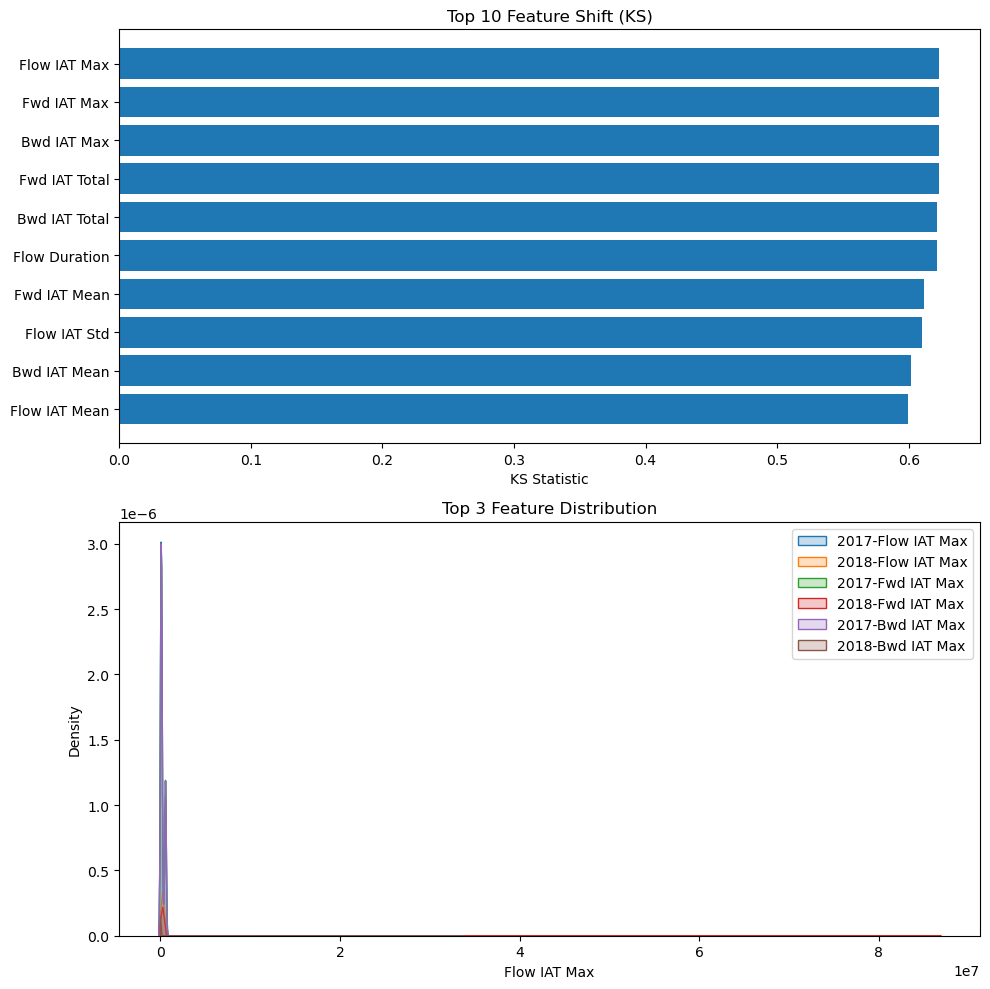

In [84]:
fig, axes = plt.subplots(2, 1, figsize=(10, 10))

# ---------------------------
# 1. KS bar chart
# ---------------------------
axes[0].barh(result_df["Feature"][:10][::-1], result_df["KS"][:10][::-1])
axes[0].set_title("Top 10 Feature Shift (KS)")
axes[0].set_xlabel("KS Statistic")

# ---------------------------
# 2. KDE (Top 3)
# ---------------------------
top3 = result_df.head(3)["Feature"].tolist()

for feat in top3:
    x = df17[feat].dropna()
    y = df18[feat].dropna()

    if len(x.unique()) > 1:
        sns.kdeplot(x, ax=axes[1], label=f"2017-{feat}", fill=True)
    if len(y.unique()) > 1:
        sns.kdeplot(y, ax=axes[1], label=f"2018-{feat}", fill=True)

axes[1].set_title("Top 3 Feature Distribution")
axes[1].legend()

plt.tight_layout()
plt.show()

In [79]:
# =========================================================
# 9. 전체 결과 저장
# =========================================================
if len(all_results) > 0:
    all_df = pd.concat(all_results, ignore_index=True)

    all_df.to_csv(
        os.path.join(save_dir, "all_pair_top20_results.csv"),
        index=False,
        encoding="utf-8-sig"
    )

    # feature별 평균 KS
    overall_summary = (
        all_df.groupby("Feature")[["KS", "Wasserstein"]]
        .mean()
        .sort_values(by="KS", ascending=False)
        .reset_index()
    )

    overall_summary.to_csv(
        os.path.join(save_dir, "overall_feature_shift_summary.csv"),
        index=False,
        encoding="utf-8-sig"
    )

    # =====================================================
    # 10. 전체 평균 KS 막대그래프
    # =====================================================
    plt.figure(figsize=(10, 7))
    plt.barh(overall_summary["Feature"][::-1], overall_summary["KS"][::-1])
    plt.xlabel("Average KS Statistic")
    plt.ylabel("Feature")
    plt.title("Overall Top 20 Shifted Features (No Destination Port)")
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, "overall_top20_average_KS_bar.png"), dpi=150)
    plt.close()

print(f"\n모든 분석 완료. 저장 폴더: {save_dir}")


모든 분석 완료. 저장 폴더: D:\dataset\label_pair_compare_top20_no_dstport
